### Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


### Load Dataset

In [3]:
train_df = '../data/raw/cs-training.csv'
df = pd.read_csv(train_df)

print("Dataframe loaded successfully!")

Dataframe loaded successfully!


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 150000
Columns: 12


In [5]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
df.columns.tolist() # to see column names in our dataset

['Unnamed: 0',
 'SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

### Columns Name Change

In [112]:
# Changing column names to more meaningful names
df = df.rename(columns={
    "Unnamed: 0": "ID",
    "SeriousDlqin2yrs": "Default",
    "RevolvingUtilizationOfUnsecuredLines": "CreditUtilization",
    "age": "Age",
    "NumberOfTime30-59DaysPastDueNotWorse": "Late30-59DaysPastDue",
    "debtRatio": "DebtRatio",
    "MonthlyIncome": "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans": "OpenCreditLines",
    "NumberOfTimes90DaysLate": "Late90DaysPastDue",
    "NumberRealEstateLoansOrLines": "RealEstateLoans",
    "NumberOfTime60-89DaysPastDueNotWorse": "Late60-89DaysPastDue",
    "NumberOfDependents": "Dependents"
})

df.head().T

,0,1,2,3,4
ID,1.000000,2.000000,3.000000,4.00000,5.000000
Default,1.000000,0.000000,0.000000,0.00000,0.000000
CreditUtilization,0.766127,0.957151,0.658180,0.23381,0.907239
Age,45.000000,40.000000,38.000000,30.00000,49.000000
Late30-59DaysPastDue,2.000000,0.000000,1.000000,0.00000,1.000000
DebtRatio,0.802982,0.121876,0.085113,0.03605,0.024926
MonthlyIncome,9120.000000,2600.000000,3042.000000,3300.00000,63588.000000
OpenCreditLines,13.000000,4.000000,2.000000,5.00000,7.000000
Late90DaysPastDue,0.000000,0.000000,1.000000,0.00000,0.000000
RealEstateLoans,6.000000,0.000000,0.000000,0.00000,1.000000


In [46]:
df.columns.tolist() 

['ID',
 'Default',
 'CreditUtilization',
 'Age',
 'Late30-59DaysPastDue',
 'DebtRatio',
 'MonthlyIncome',
 'OpenCreditLines',
 'Late90DaysPastDue',
 'RealEstateLoans',
 'Late60-89DaysPastDue',
 'Dependents']

### Data Information

In [47]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    150000 non-null  int64  
 1   Default               150000 non-null  int64  
 2   CreditUtilization     150000 non-null  float64
 3   Age                   150000 non-null  int64  
 4   Late30-59DaysPastDue  150000 non-null  int64  
 5   DebtRatio             150000 non-null  float64
 6   MonthlyIncome         120269 non-null  float64
 7   OpenCreditLines       150000 non-null  int64  
 8   Late90DaysPastDue     150000 non-null  int64  
 9   RealEstateLoans       150000 non-null  int64  
 10  Late60-89DaysPastDue  150000 non-null  int64  
 11  Dependents            146076 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 13.7 MB


### Missing Values

In [48]:
missing_values = df.isnull().sum() # to check missing values in each column
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
MonthlyIncome    29731
Dependents        3924
dtype: int64


In [78]:
missing_summary = pd.DataFrame({'Missing Count': df.isnull().sum(), 'Percentage(%)': df.isnull().mean() * 100})
missing_summary[missing_summary['Missing Count'] > 0]

,Missing Count,Percentage(%)
MonthlyIncome,29731,19.820667
Dependents,3924,2.616000


### Duplicate Rows and IDs

In [49]:
# Checking for duplicate rows and duplicate IDs
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate ID's:", df['ID'].duplicated().sum())

Duplicate rows: 0
Duplicate ID's: 0


### Default Counts

In [56]:
# Count of each category in the 'Default' column --> 0=No Default, 1=Default
df['Default'].value_counts()

Default
0    139974
1     10026
Name: count, dtype: int64

In [55]:
# Percentage of each category in the 'Default' column --> 0=No Default, 1=Default
df['Default'].value_counts(normalize=True) * 100

Default
0    93.316
1     6.684
Name: proportion, dtype: float64

### Visualising Default Counts

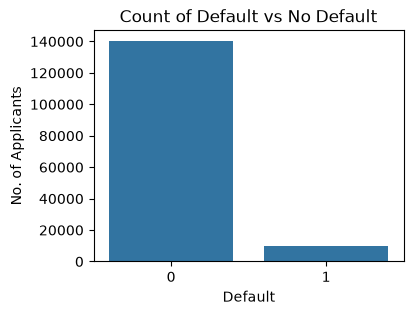

In [62]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df, x='Default')
plt.title('Count of Default vs No Default')
plt.xlabel('Default')
plt.ylabel('No. of Applicants')
plt.show()

In [72]:
target_count = df['Default'].value_counts()
total_count = len(df)

print(f"Total number of applicants: {total_count:,}")
print(f"Non-Default: {target_count[0]:,}")
print(f"Non-Default Percentage: {target_count[0] / total_count * 100:.2f}%")
print(f"Default: {target_count[1]:,}")
print(f"Default Percentage: {target_count[1] / total_count * 100:.2f}%")

Total number of applicants: 150,000
Non-Default: 139,974
Non-Default Percentage: 93.32%
Default: 10,026
Default Percentage: 6.68%


### Data Describe

In [105]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
Default,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
CreditUtilization,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
Age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
Late30-59DaysPastDue,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
OpenCreditLines,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
Late90DaysPastDue,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
RealEstateLoans,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


### Unique Values

In [103]:
for column in df.columns:
    print(f"\n{column}")
    print("Unique Values:", df[column].nunique())


ID
Unique Values: 150000

Default
Unique Values: 2

CreditUtilization
Unique Values: 125728

Age
Unique Values: 86

Late30-59DaysPastDue
Unique Values: 16

DebtRatio
Unique Values: 114194

MonthlyIncome
Unique Values: 13594

OpenCreditLines
Unique Values: 58

Late90DaysPastDue
Unique Values: 19

RealEstateLoans
Unique Values: 28

Late60-89DaysPastDue
Unique Values: 13

Dependents
Unique Values: 13


### Understaing Age in Dataset

In [107]:
print("Minimum Age:", df['Age'].min())
print("Maximum Age:", df['Age'].max())
print("Mean Age:", f"{df['Age'].mean():.2f}")
print("Median Age:", df['Age'].median())
print("Standard Deviation of Age:", f"{df['Age'].std():.2f}")
print("\n")
print("Applicants with Age < 18:")
display(df[df['Age'] < 18])
print("\n")
print("Applicants with Age >= 100:")
display(df[df['Age'] >= 100])
print("\n")


Minimum Age: 0
Maximum Age: 109
Mean Age: 52.30
Median Age: 52.0
Standard Deviation of Age: 14.77


Applicants with Age < 18:


,ID,Default,CreditUtilization,Age,Late30-59DaysPastDue,DebtRatio,MonthlyIncome,OpenCreditLines,Late90DaysPastDue,RealEstateLoans,Late60-89DaysPastDue,Dependents
65695,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0




Applicants with Age >= 100:


,ID,Default,CreditUtilization,Age,Late30-59DaysPastDue,DebtRatio,MonthlyIncome,OpenCreditLines,Late90DaysPastDue,RealEstateLoans,Late60-89DaysPastDue,Dependents
7763,7764,0,0.069167,101,0,50.000000,NaN,2,0,0,0,0.0
19884,19885,0,1.000000,103,0,0.000000,1600.0,3,0,0,0,0.0
25561,25562,0,0.009866,102,0,0.002424,3300.0,3,0,0,0,0.0
40007,40008,0,0.064748,107,0,939.000000,NaN,9,0,1,0,0.0
56761,56762,0,0.003469,105,0,2.000000,NaN,4,0,0,0,NaN
57967,57968,0,0.001397,103,0,1798.500000,1.0,11,0,2,0,0.0
90937,90938,0,0.000000,102,0,0.000000,NaN,12,0,0,0,0.0
93813,93814,0,0.025780,101,0,0.013797,1666.0,5,0,0,0,0.0
96450,96451,0,0.109642,102,0,0.273844,3417.0,7,0,0,0,1.0
105790,105791,0,0.109307,109,0,2141.000000,NaN,17,0,1,0,NaN


### Analizing Delinquency Columns

In [114]:
past_due_columns = ['Late30-59DaysPastDue', 'Late60-89DaysPastDue', 'Late90DaysPastDue']

for column in past_due_columns:
    print("\n")
    print(df[column].value_counts().sort_index())



Late30-59DaysPastDue
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64


Late60-89DaysPastDue
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64


Late90DaysPastDue
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64


### Analizing Credit Utilization

In [115]:
df['CreditUtilization'].describe()

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: CreditUtilization, dtype: float64

In [124]:
# Rows with CreditUtilization > 1
high_credit_utilization = (df['CreditUtilization'] > 1).sum()
print(high_credit_utilization)

3321


### Analizing DebtRatio

In [127]:
df['DebtRatio'].describe()

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
max      329664.000000
Name: DebtRatio, dtype: float64

In [129]:
# rows with DebtRatio > 1
high_debt_ratio = (df['DebtRatio'] > 1).sum() 
print(high_debt_ratio)

35137


### Feature Distributions Graphs

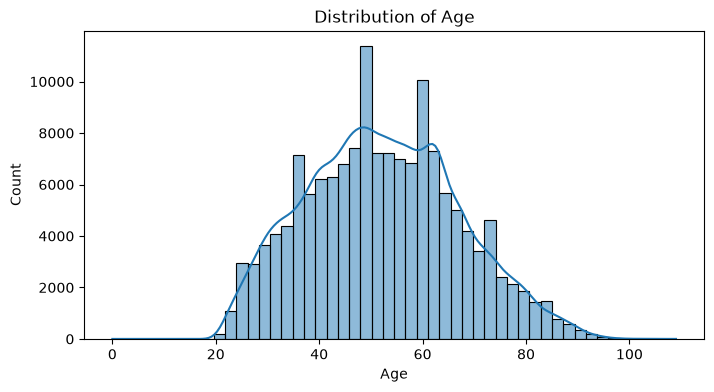

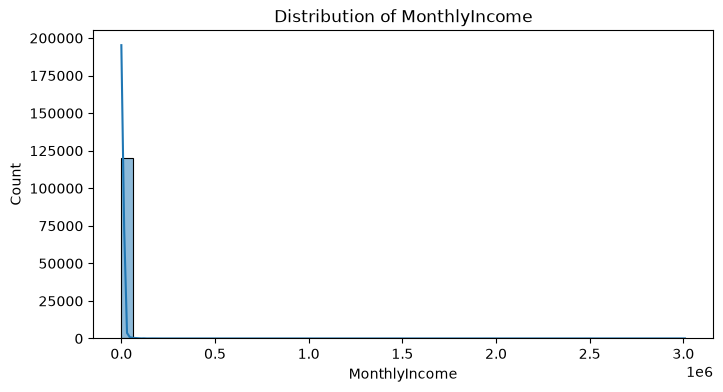

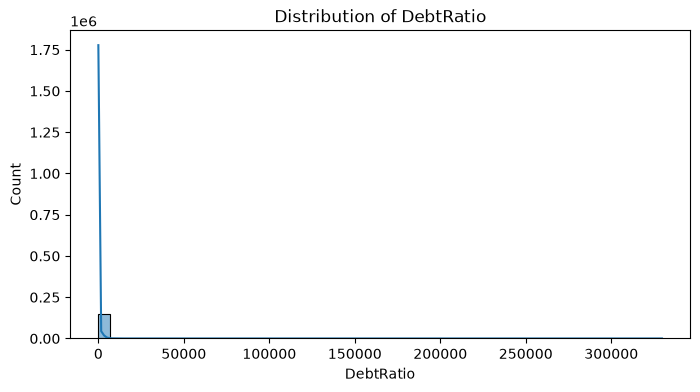

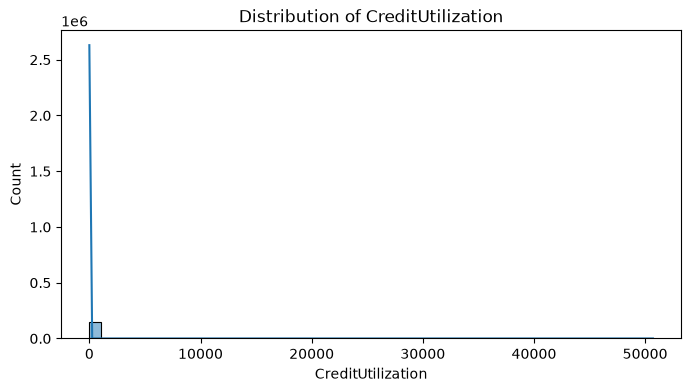

In [141]:
features = [
    'Age',
    'MonthlyIncome',
    'DebtRatio',
    'CreditUtilization'
]

for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, bins=50, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

### Feature Vs Target

In [142]:
df.groupby('Default')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,139974.0,52.751375,14.791079,0.0,42.0,52.0,63.0,109.0
1,10026.0,45.926591,12.916289,21.0,36.0,45.0,54.0,101.0


In [151]:
df.groupby('Default')['DebtRatio'].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,139974.0,357.151168,2083.282060,0.0,0.173707,0.362659,0.865608,329664.0
1,10026.0,295.121066,1238.360283,0.0,0.193979,0.428227,0.892371,38793.0


In [152]:
df.groupby('Default')['CreditUtilization'].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,139974.0,6.168855,256.126350,0.0,0.026983,0.133288,0.487686,50708.0
1,10026.0,4.367282,131.835778,0.0,0.398219,0.838853,1.000000,8328.0


In [153]:
df.groupby('Default')['RealEstateLoans'].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,139974.0,1.020368,1.105512,0.0,0.0,1.0,2.0,54.0
1,10026.0,0.988530,1.425723,0.0,0.0,1.0,2.0,29.0


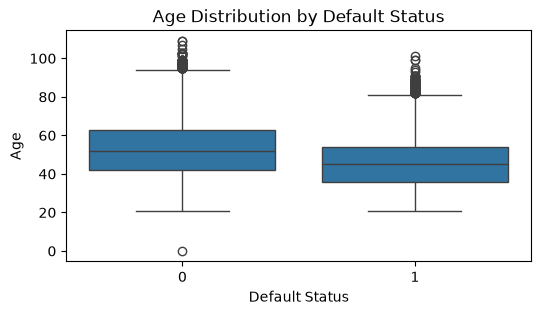

In [157]:
plt.figure(figsize=(6, 3))
sns.boxplot(
    data=df, x='Default', y='Age'
)
plt.title("Age Distribution by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Age")
plt.show()

### Data Quality  Report

In [159]:
data_quality = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100,
    "unique_value": df.nunique()
})

data_quality

,dtype,missing_count,missing_percentage,unique_value
ID,int64,0,0.000000,150000
Default,int64,0,0.000000,2
CreditUtilization,float64,0,0.000000,125728
Age,int64,0,0.000000,86
Late30-59DaysPastDue,int64,0,0.000000,16
DebtRatio,float64,0,0.000000,114194
MonthlyIncome,float64,29731,19.820667,13594
OpenCreditLines,int64,0,0.000000,58
Late90DaysPastDue,int64,0,0.000000,19
RealEstateLoans,int64,0,0.000000,28
